# Bayesian Optimization

Imagine you need to find the best settings for a complex system – perhaps tuning the hyperparameters of a deep learning model, optimizing the design of an experiment, or finding the ideal parameters for a simulation. Often, evaluating the system with a given set of parameters (i.e., running the experiment or training the model) is expensive, time-consuming, or resource-intensive. How can you find the optimal settings without performing an exhaustive search?

This is where **Bayesian Optimization (BO)** comes in. It's a powerful, sequential strategy designed specifically for the **global optimization of black-box functions**. These are functions where:

1.  We don't know the underlying mathematical form (it's a "black box").
2.  Evaluating the function (getting an output `y` for an input `x`) is costly.
3.  We often cannot compute derivatives (gradients).
4.  The observations might be noisy (the output `y` can vary even for the same input `x`).

BO tackles this challenge by intelligently choosing the next point to evaluate, aiming to find the optimum (maximum or minimum) in as few evaluations as possible.

### Core Components

Bayesian Optimization cleverly balances exploring unknown parts of the search space and exploiting areas known to yield good results. It does this using two main components:

1.  **A Probabilistic Surrogate Model:** This model approximates the unknown objective function based on the points observed so far. It also provides uncertainty estimates about the function's behavior in unexplored regions. Gaussian Processes (GPs) are the most common choice for this surrogate model due to their flexibility and inherent uncertainty quantification.
2.  **An Acquisition Function:** This function uses the surrogate model's predictions (mean and uncertainty) to determine the 'utility' of evaluating any given point in the search space. It guides the search by suggesting the point that is most likely to lead to an improvement, considering both the predicted performance and the uncertainty. Examples include Expected Improvement (EI) and Upper Confidence Bound (UCB).

### The Iterative Process

The BO algorithm works iteratively:

1.  **Observe:** Evaluate the black-box function at one or more points chosen by the acquisition function.
2.  **Update:** Update the surrogate model (e.g., the Gaussian Process) using all the data collected so far (inputs and their observed outputs).
3.  **Select:** Optimize the acquisition function (which is cheap to evaluate) over the search space to find the most promising point(s) to evaluate next.
4.  **Repeat:** Continue this cycle until a stopping criterion is met (e.g., budget of function evaluations exhausted, desired performance level reached).


### Recommended reading:
1. [A Tutorial on Bayesian Optimization](https://arxiv.org/pdf/1807.02811)
1. [BayesOpt docs](https://bayesian-optimization.github.io/BayesianOptimization/2.0.3/)
1. [Exploring Bayesian Optimization](https://distill.pub/2020/bayesian-optimization/)
1. [Acquisition functions in Bayesian Optimization](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html)
1. [A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/)
1. [Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

### Define and visualize the target function
First, we'll create a synthetic objective function to optimize. This specific function has three peaks (at x=0, x≈2 and x≈6) and is a toy example.

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$

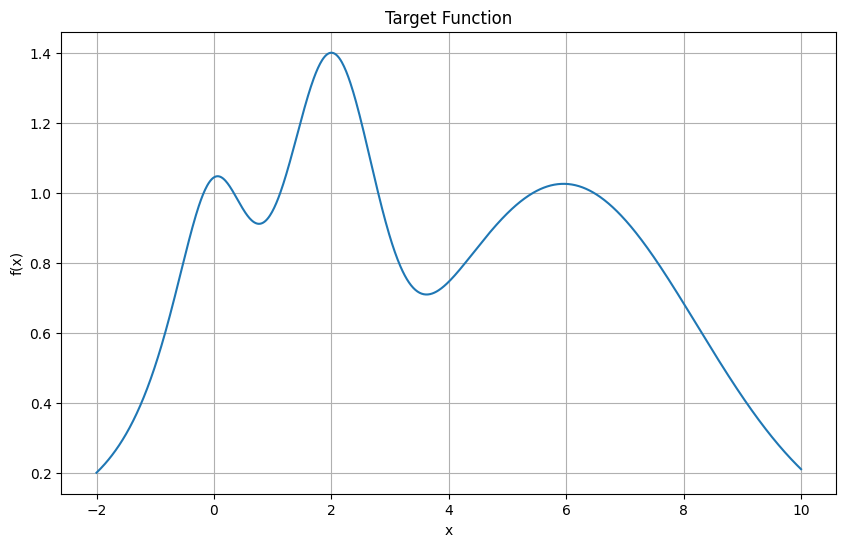

In [3]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### Define visualization functions
These helper functions will visualize the Gaussian Process model
and acquisition function at each step of the optimization process.
They help us understand how the model evolves as more observations are made.

In [6]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=8, label="Observations", color="r"
    )
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

We'll now see Bayesian Optimization in action, step by step.
At each step, observe:
1. How the GP model (dashed line) is updated
2. How the confidence interval (light blue area) changes
3. How the acquisition function (purple line) guides the next sample
4. Where the next sample point (gold star) is placed

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |

Step 0: Initial random points


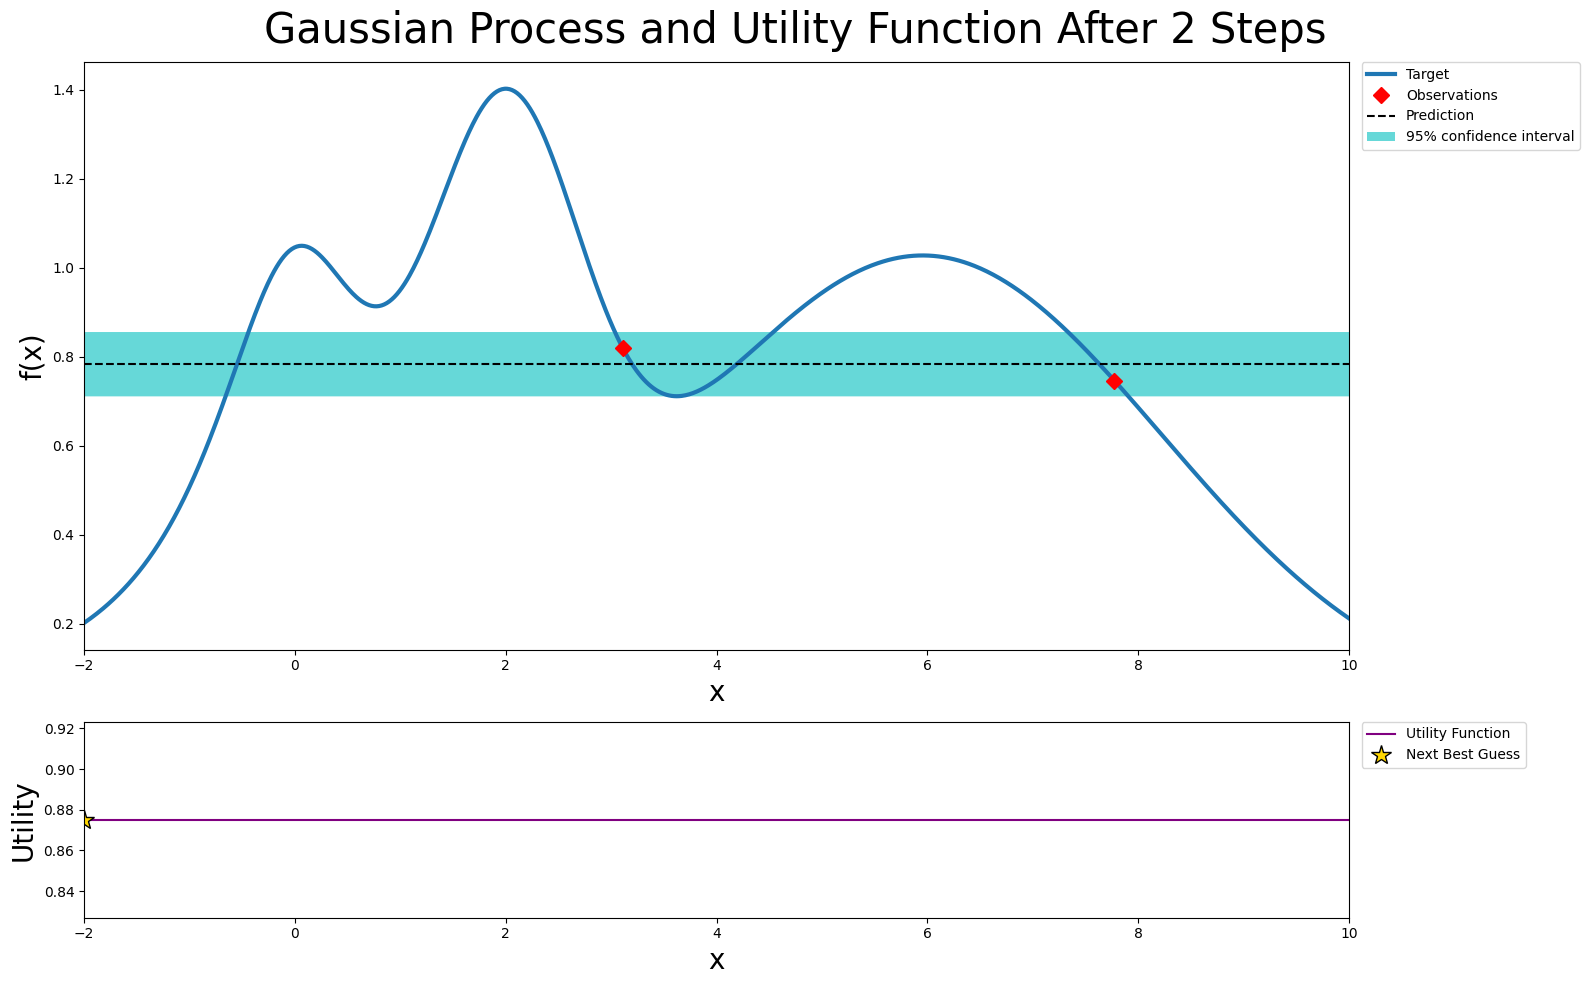

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.8190422 | 3.1102721 |

Step 1: Added a new observation


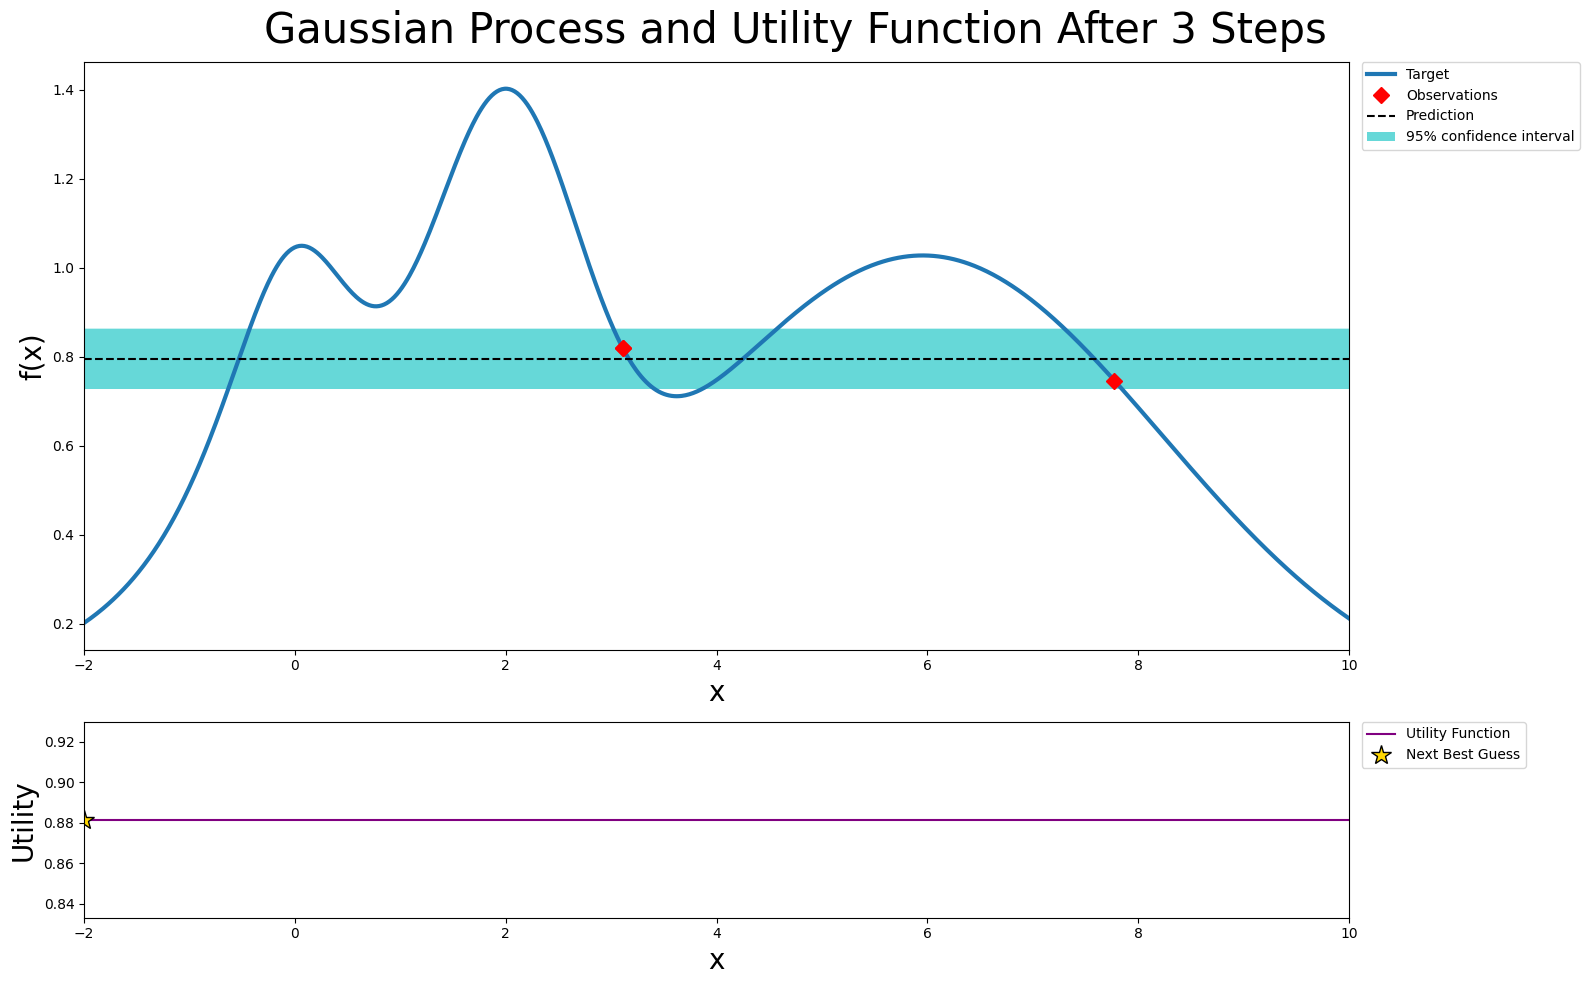

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.8943137 | 2.9649330 |

Step 2: Added a new observation


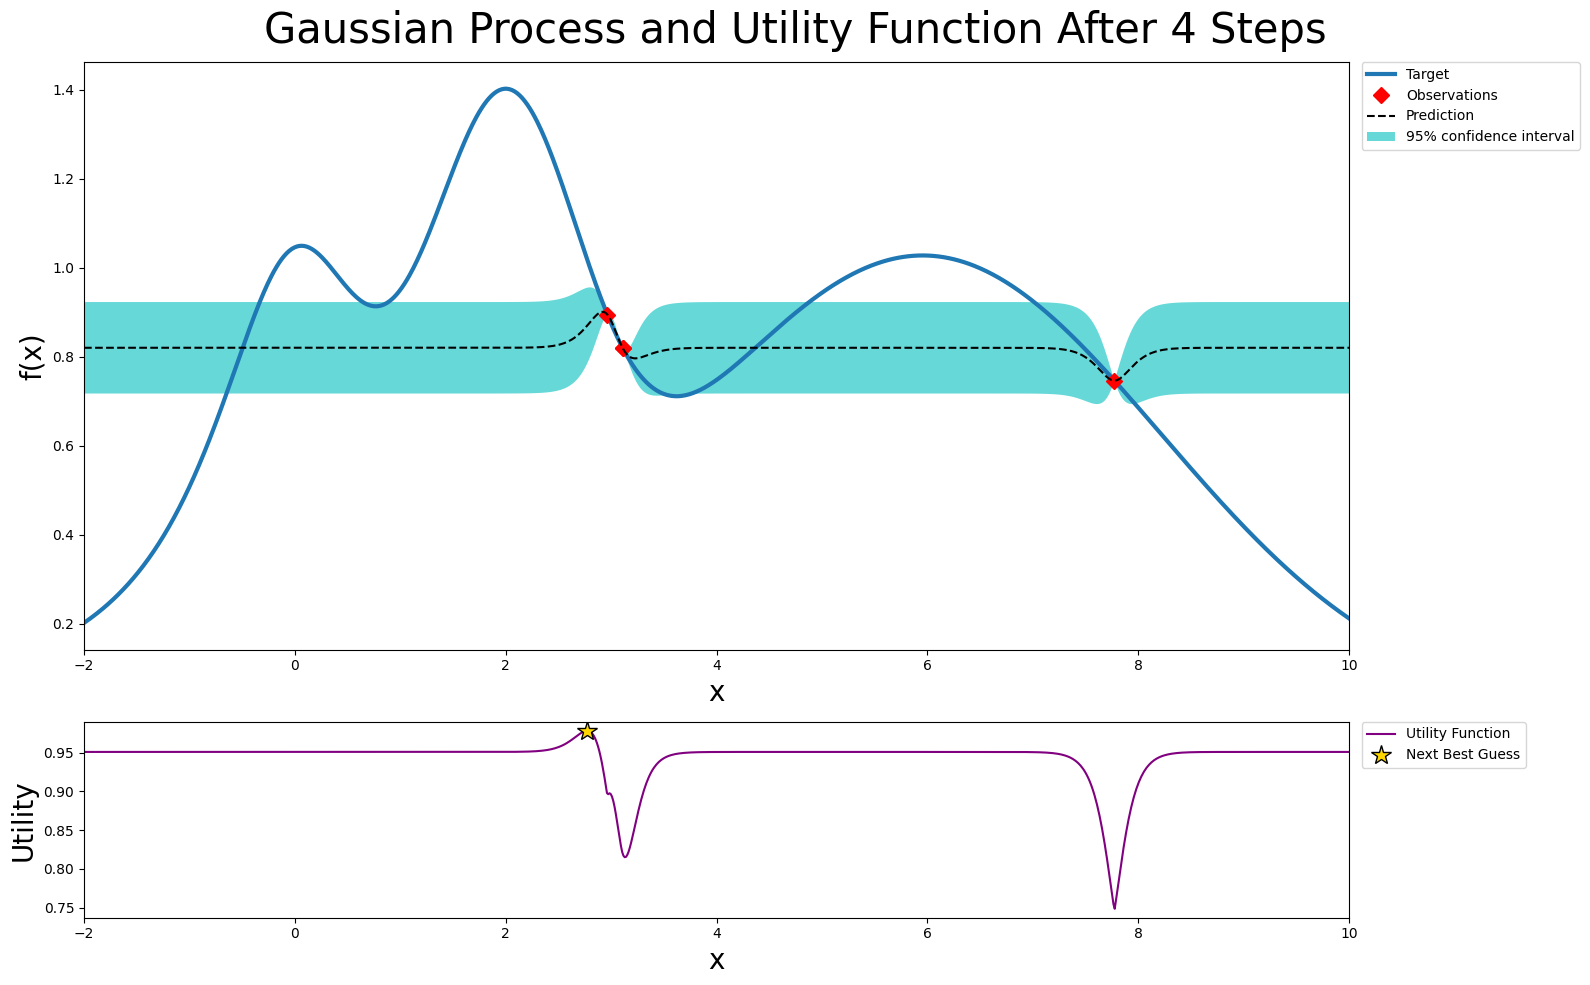

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.0188850 | 2.7720553 |

Step 3: Added a new observation


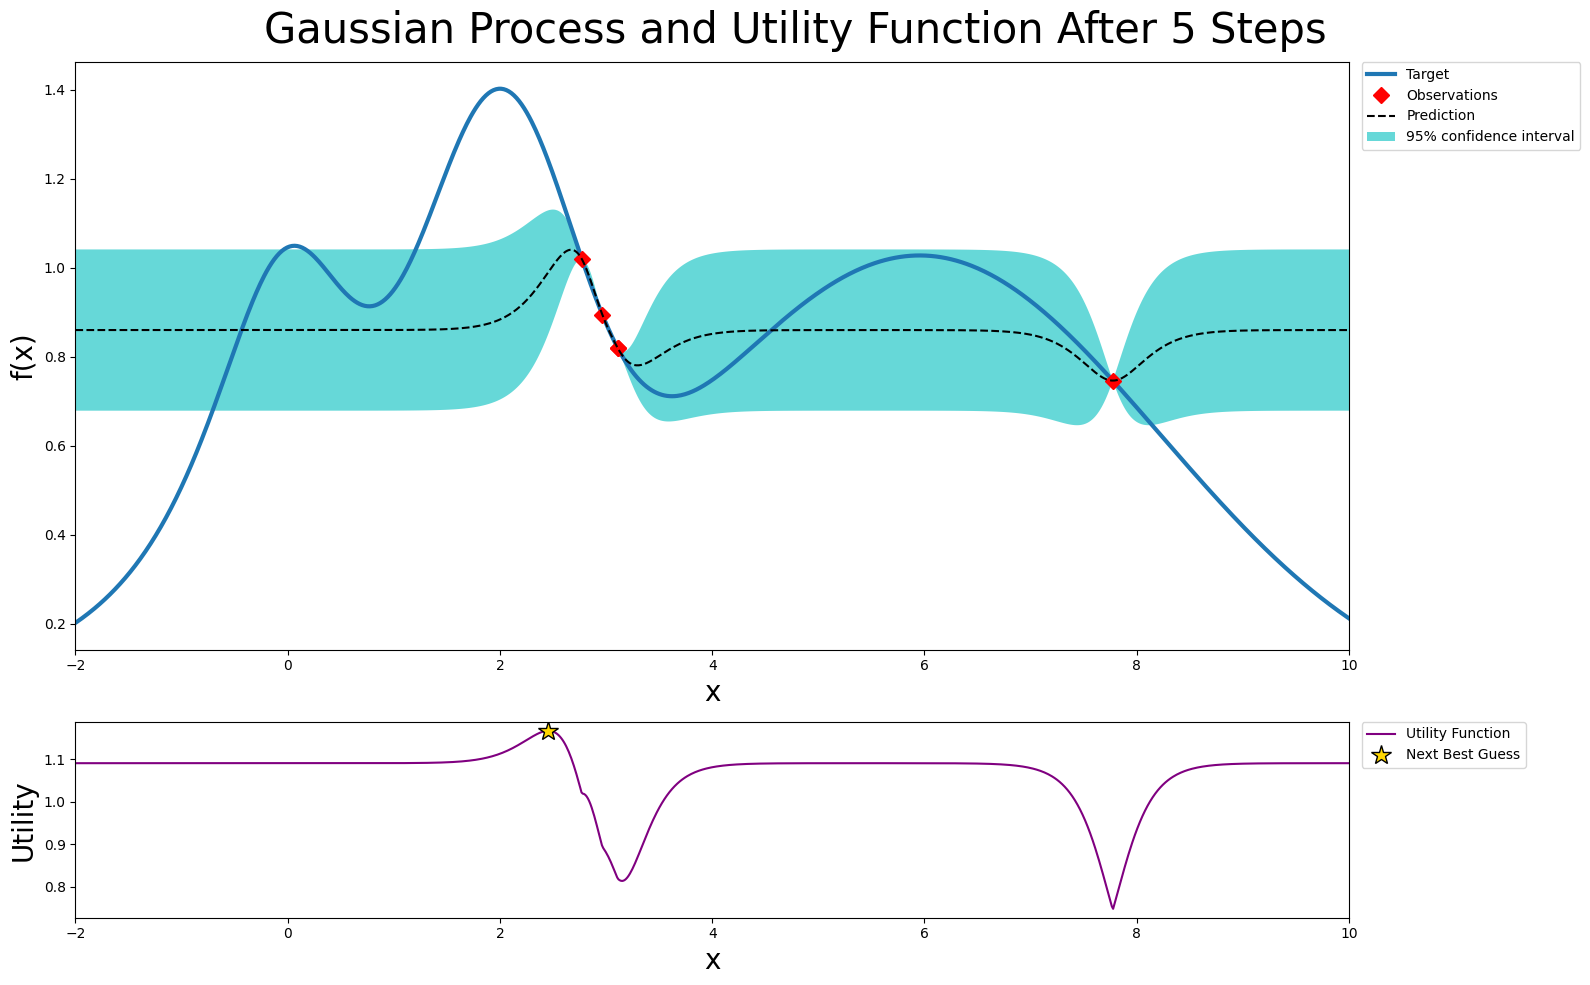

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 1.2389518 | 2.4564828 |

Step 4: Added a new observation


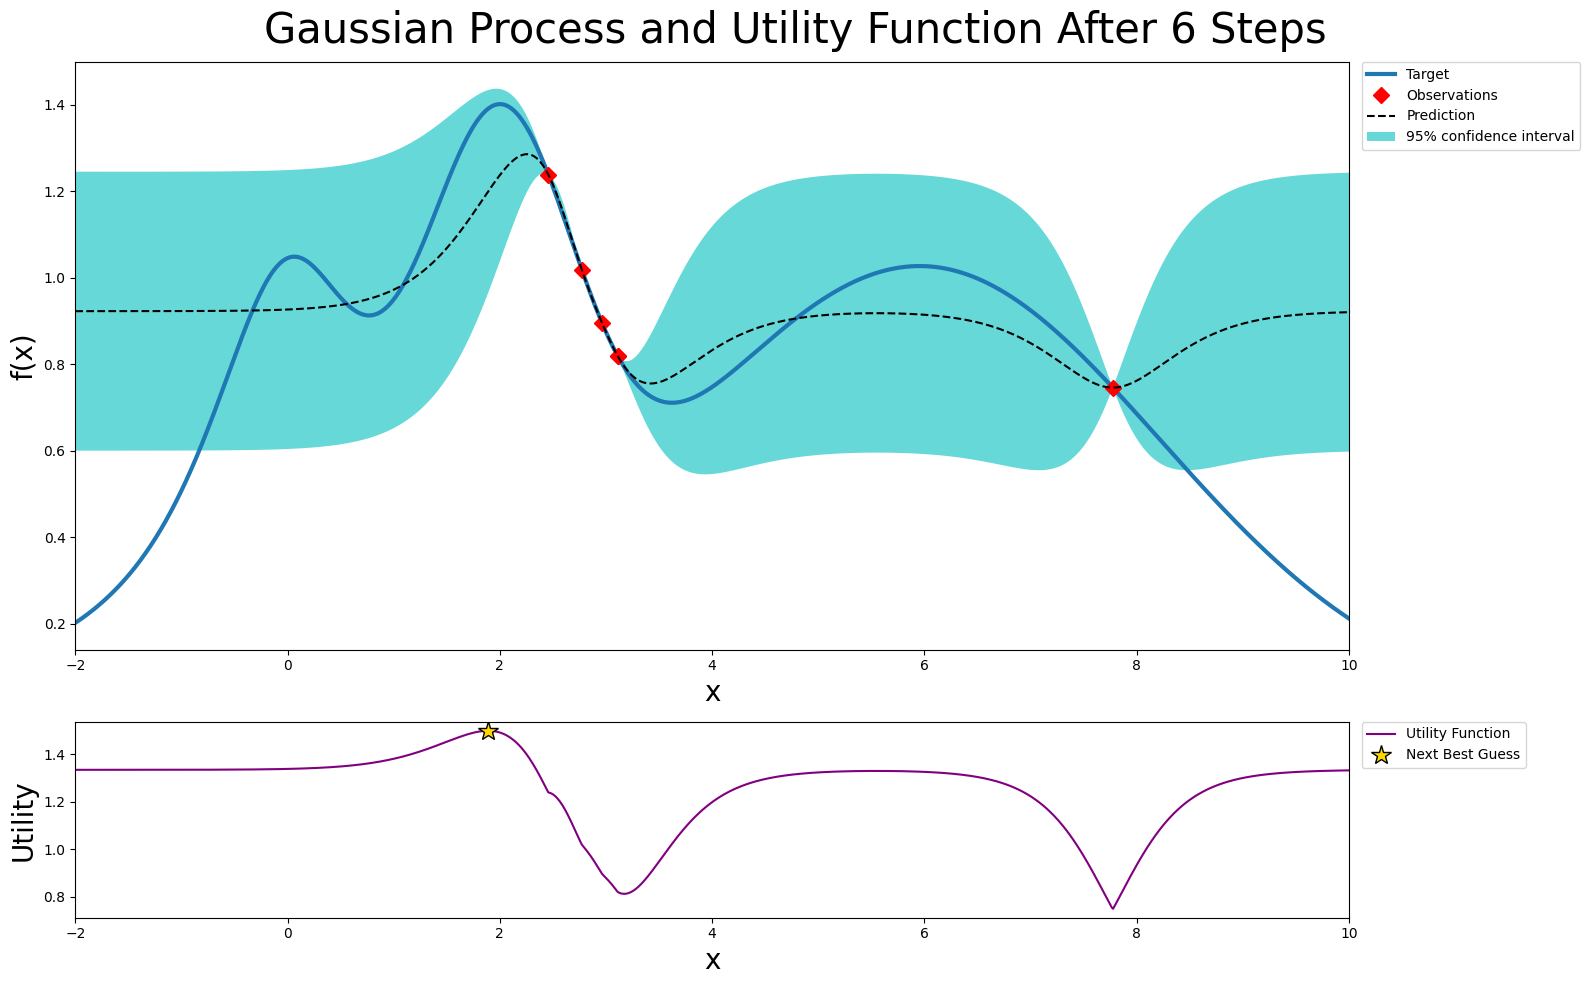

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 1.3911164 | 1.8887339 |

Step 5: Added a new observation


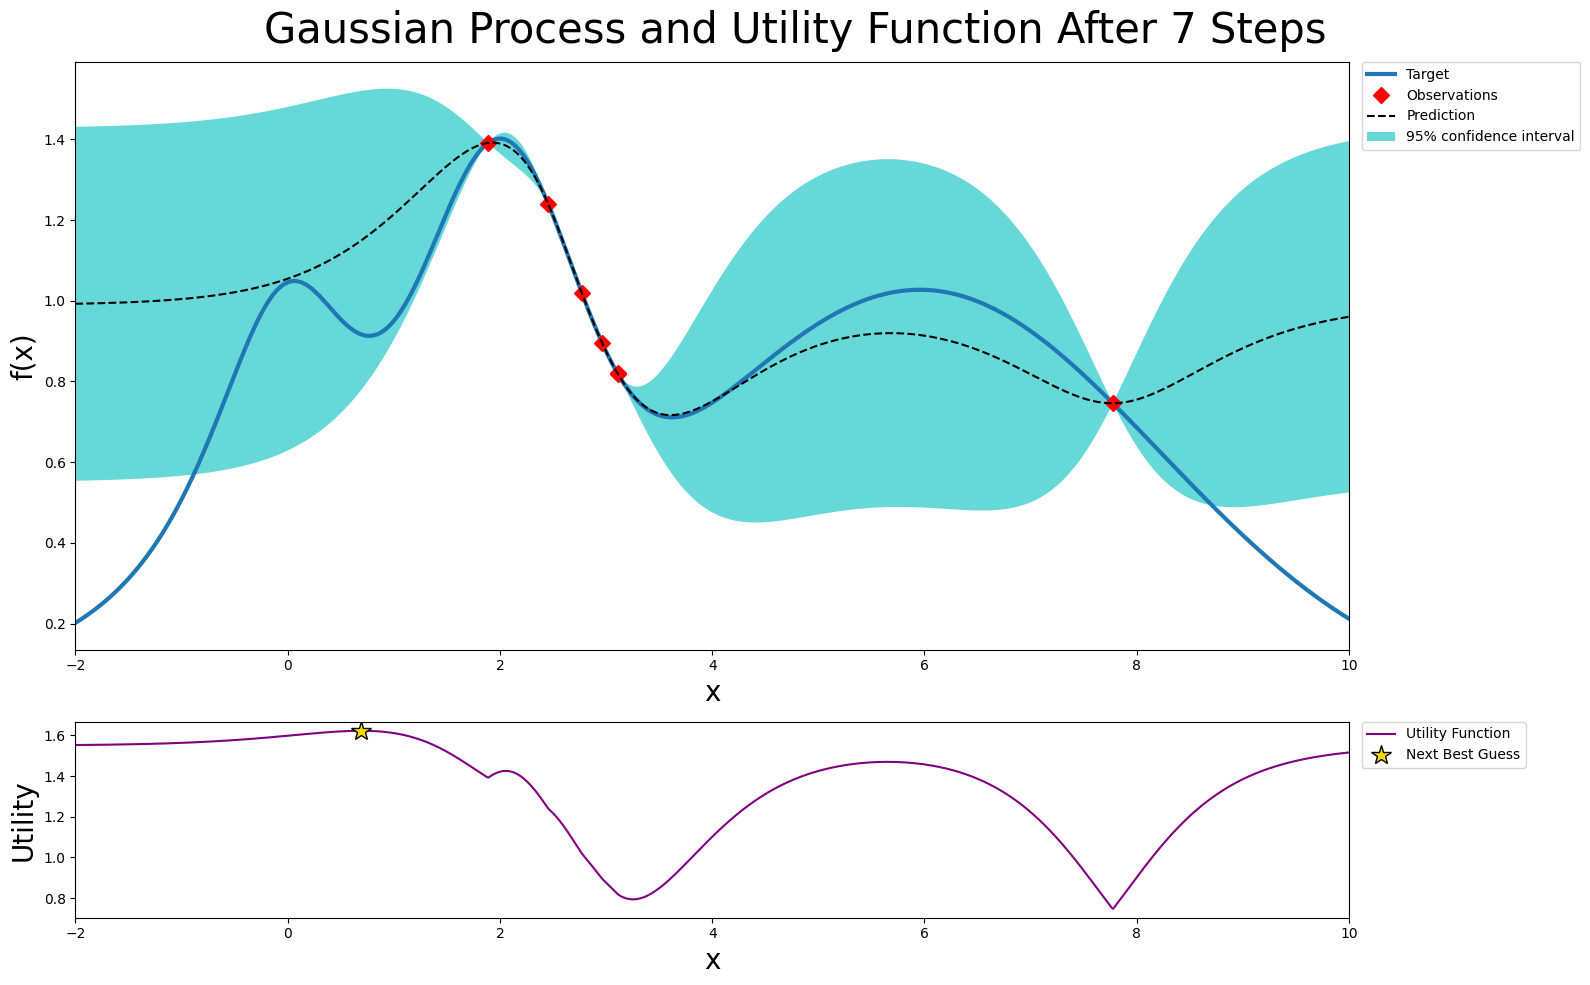


Final result:
Best target value found: 1.3911
Best input value found: x = 1.8887


In [8]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

Acquisition functions guide the sampling process by balancing:
- Exploitation: Sampling where the model predicts high values
- Exploration: Sampling where the model is uncertain

We'll compare three different acquisition functions:
1. Upper Confidence Bound (UCB): Balances exploration and exploitation
2. Probability of Improvement (PI): More exploitative
3. Greedy: Purely exploitative (custom implementation)

In [9]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856628 | -0.211814 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507499 |

UCB Acquisition Function Results:


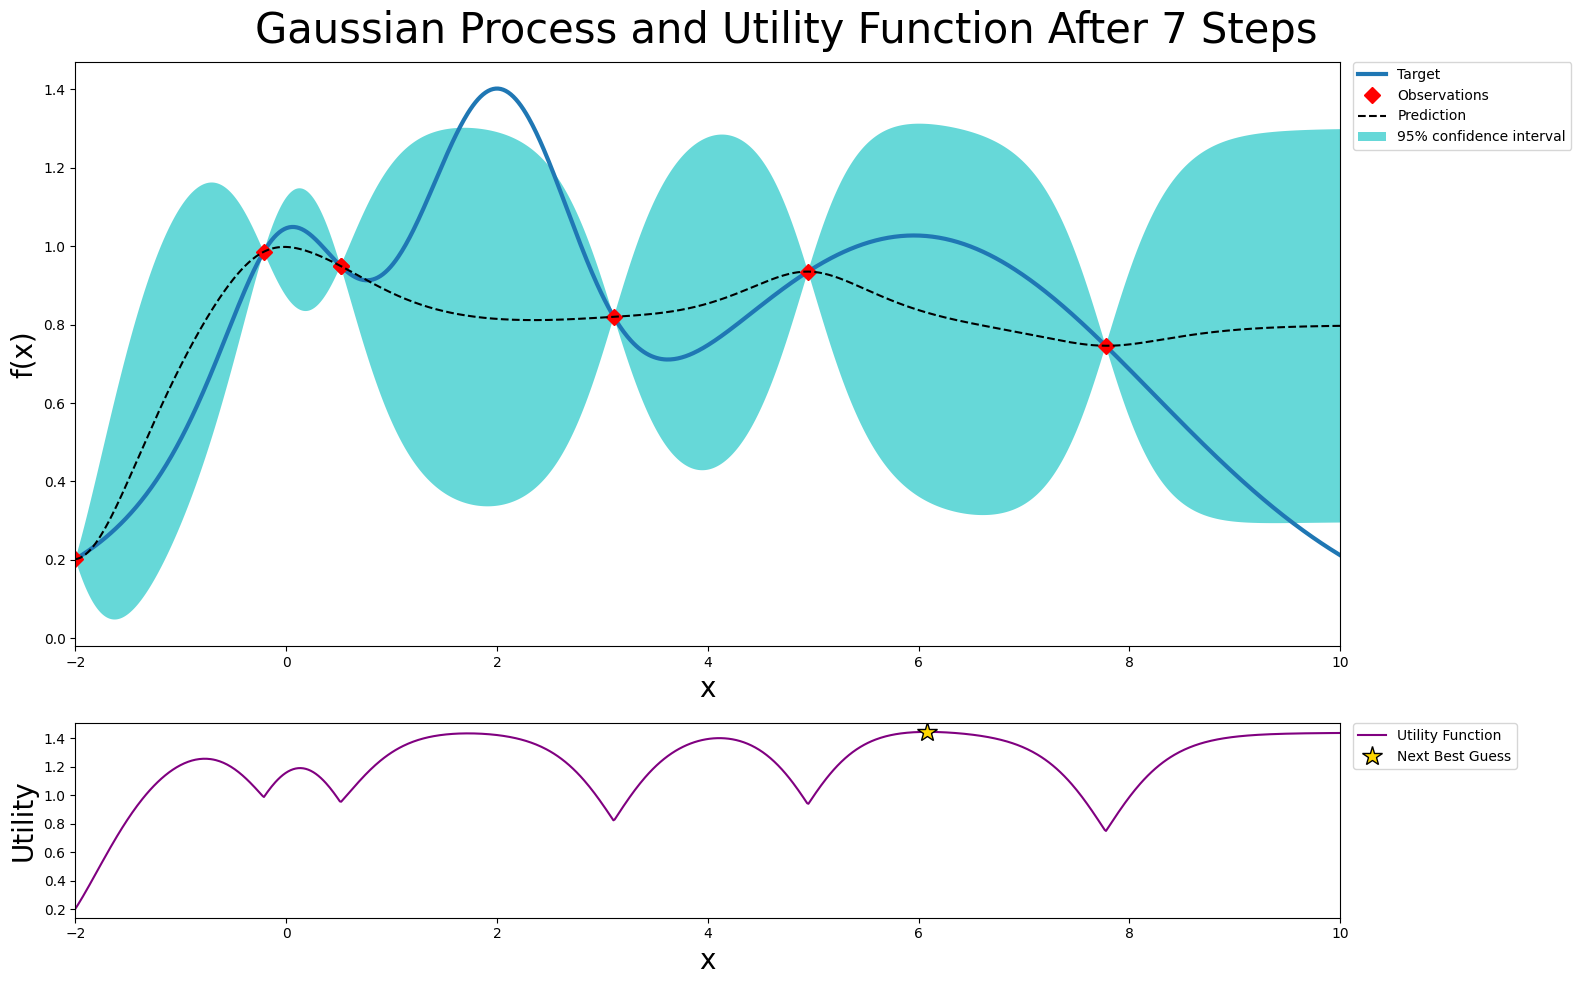

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


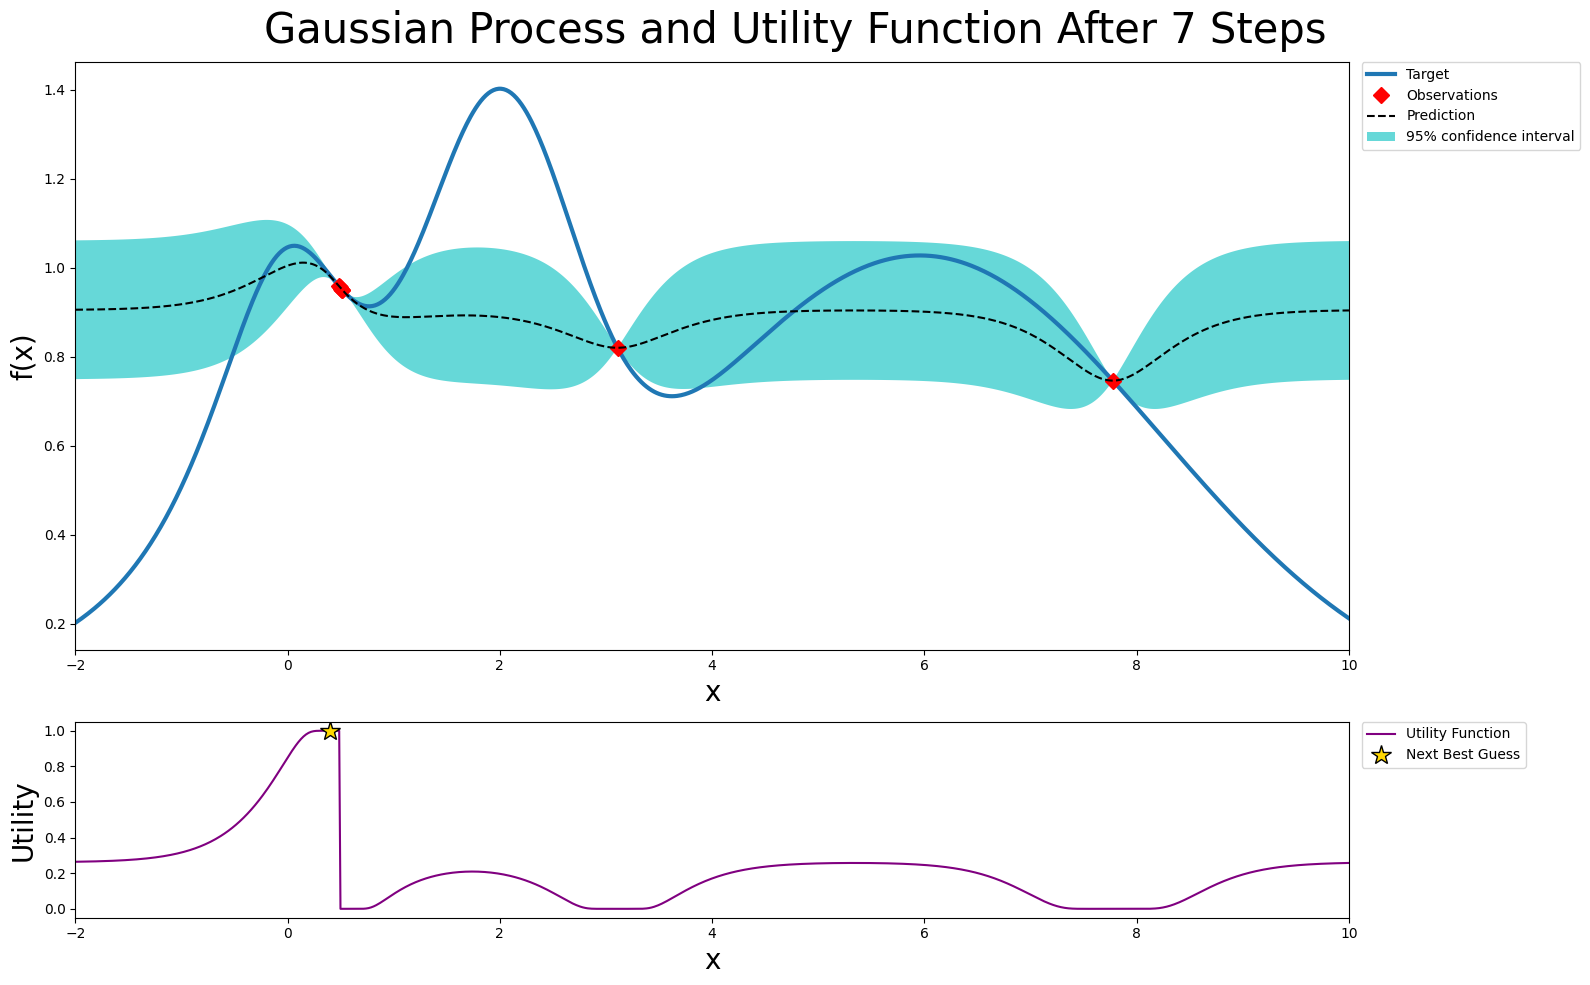

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy (Purely Exploitative) Acquisition Function Results:


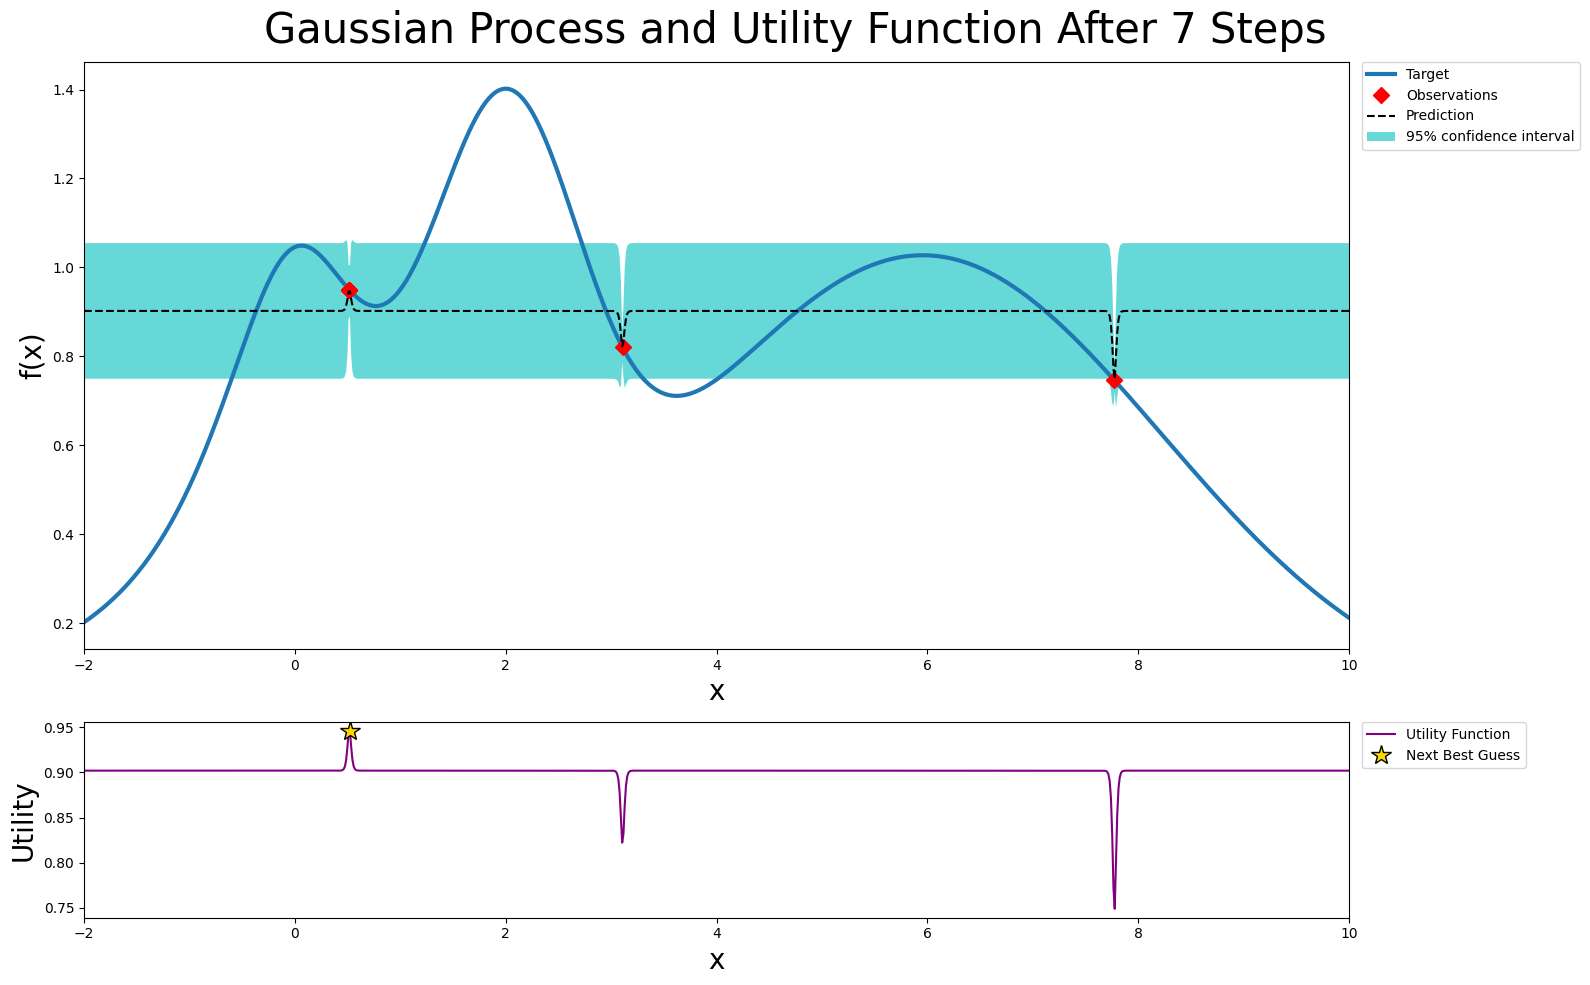


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [11]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Comment these results. Write your observations in a Markdown cell.

Due to the strict 7-step budget limit, none of the tested algorithms found the true global maximum (which sits at approximately 1.4 near x = 2).

Both the Greedy and Probability of Improvement (PI) strategies yielded the lowest scores. They over-indexed on exploitation, causing them to immediately get stuck in a local optimum near x = 0.5 while completely ignoring vast, unexplored regions of the function.

Upper Confidence Bound (UCB) achieved the highest overall score (0.9857). It effectively used its budget to explore the wider search space. Although it ran out of iterations before climbing the highest peak, its utility curve successfully identified the exact location of the true global maximum, setting it up for success if given more steps.

Exercise 1: UCB
---------------

The parameter kappa in the UCB acquisition function controls the trade-off between:
- Exploration (high kappa): More emphasis on the uncertainty
- Exploitation (low kappa): More emphasis on the predicted mean

Compare results for UCB using 3 different values:
1. kappa = 0.1 (Mostly exploitation)
2. kappa = 2.5 (Balanced)
3. kappa = 5.0 (Mostly exploration)

Review this [blog post](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html) and explain the underlying concept of UCB in a Markdown cell.

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495496 | 0.5165830 |
| 5         | 0.9561417 | 0.4919817 |
| 6         | 1.0125033 | 0.2974808 |
| 7         | 1.0463086 | 0.0066686 |

UCB Acquisition Function Results (kappa=0.1):


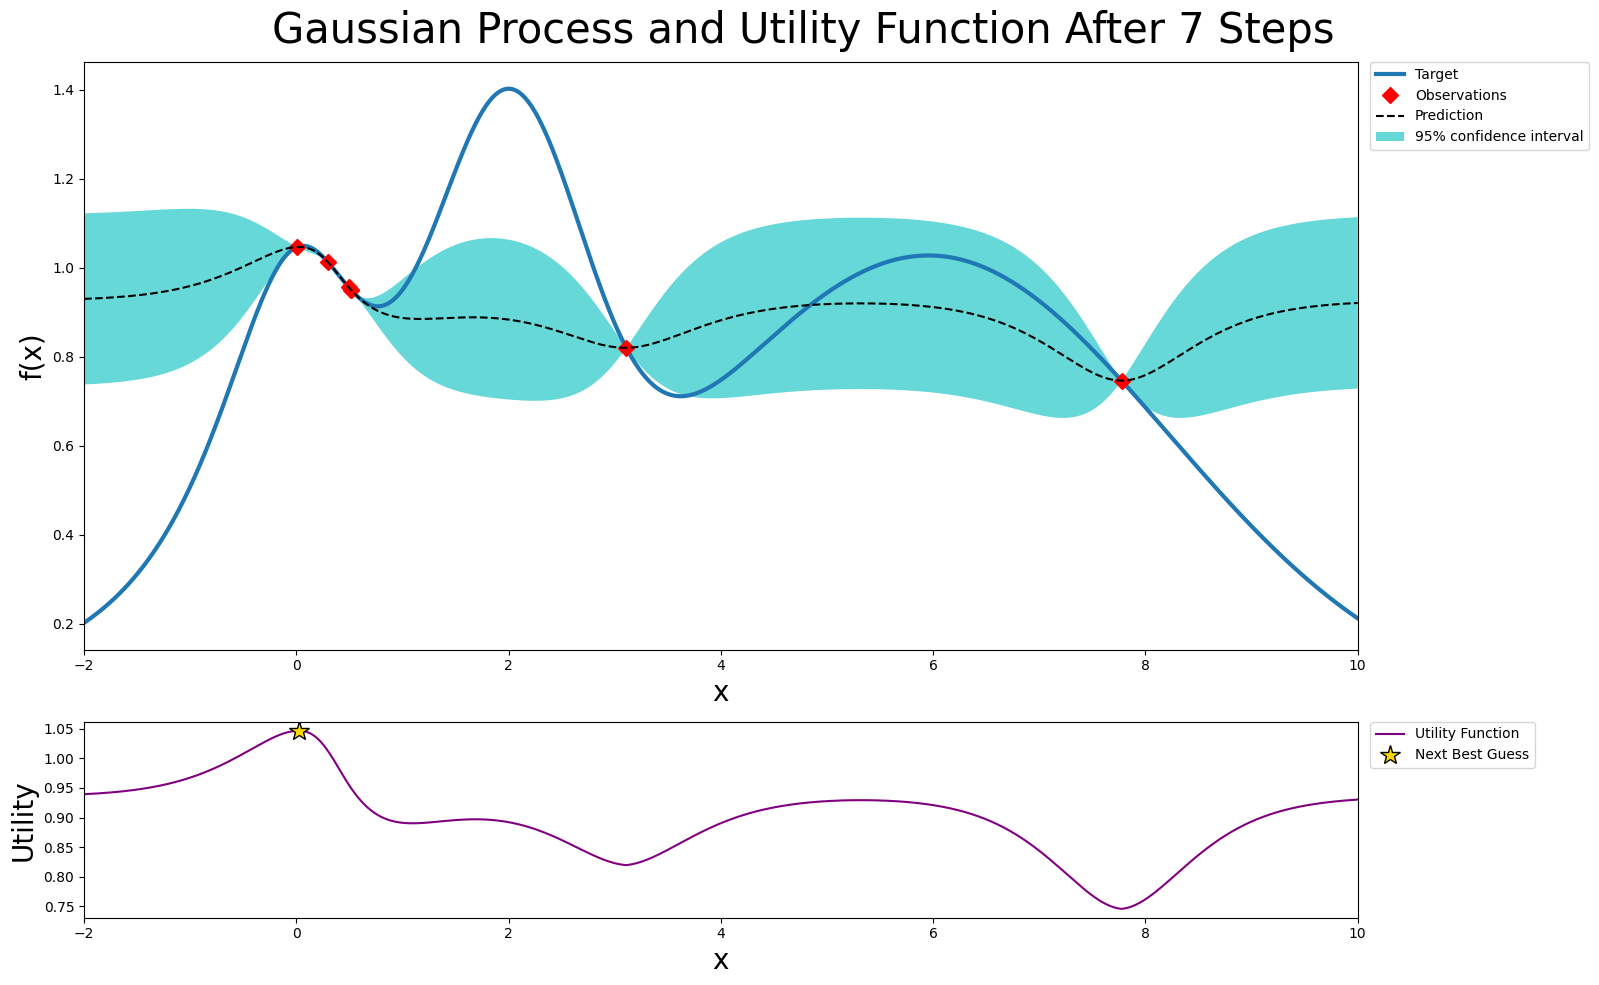

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856628 | -0.211814 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507499 |

UCB Acquisition Function Results (kappa=2.5):


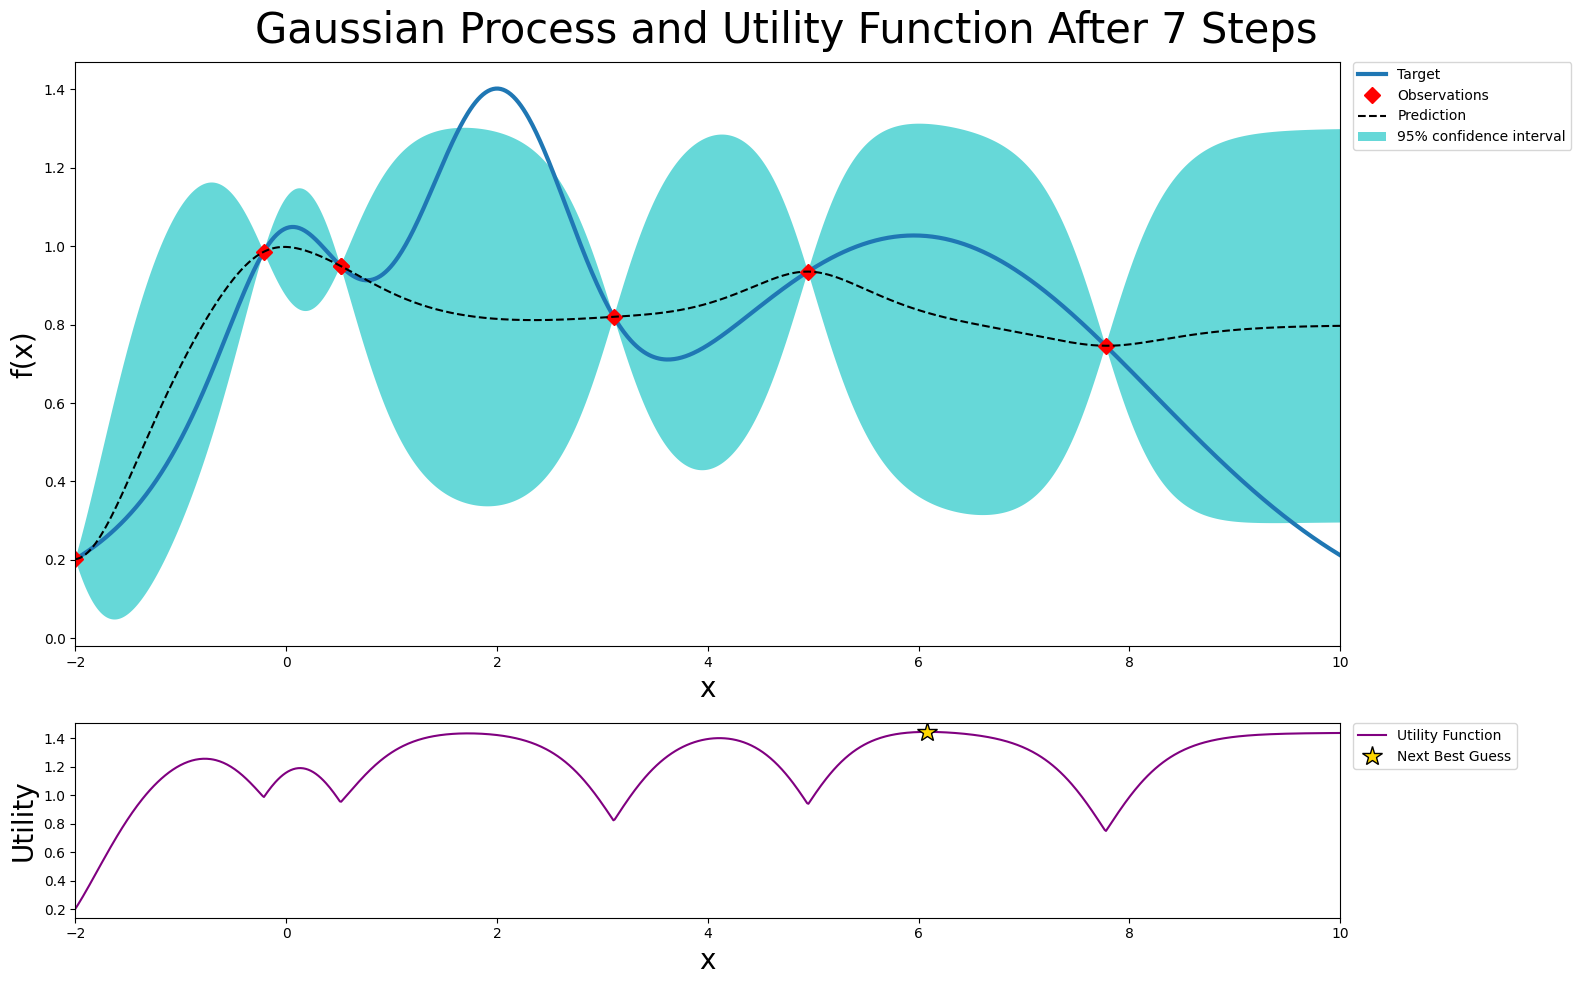

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.8354164 | -0.471659 |
| 6         | 0.9452007 | 0.9845190 |
| 7         | 0.2117975 | 10.0      |

UCB Acquisition Function Results (kappa=5.0):


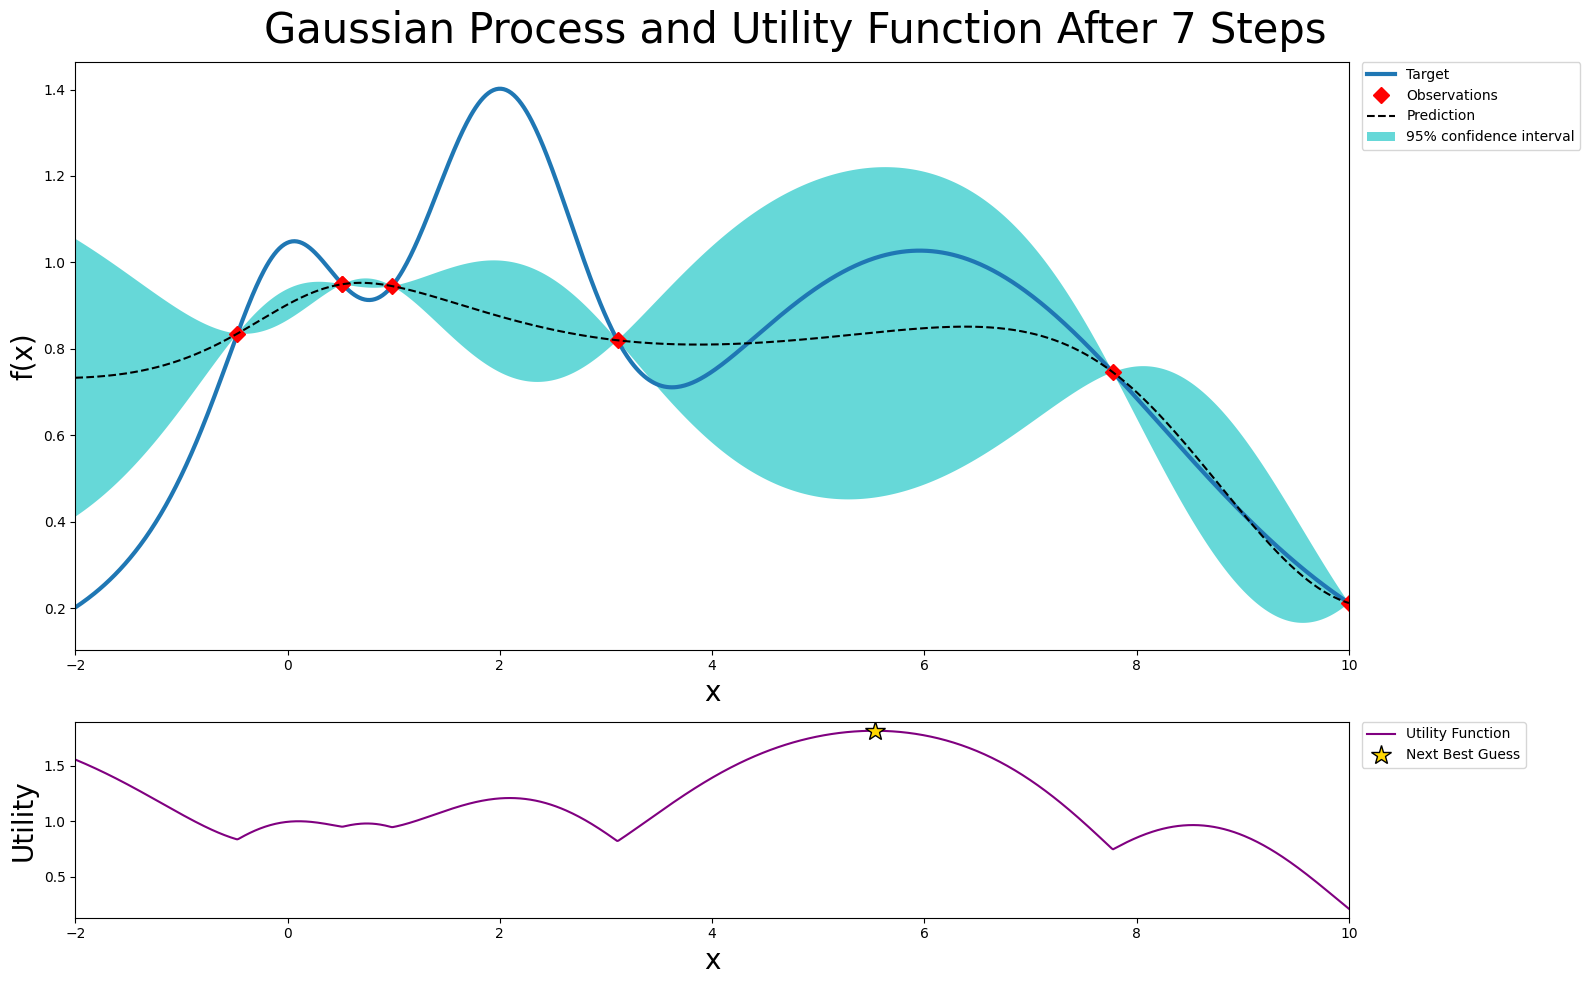

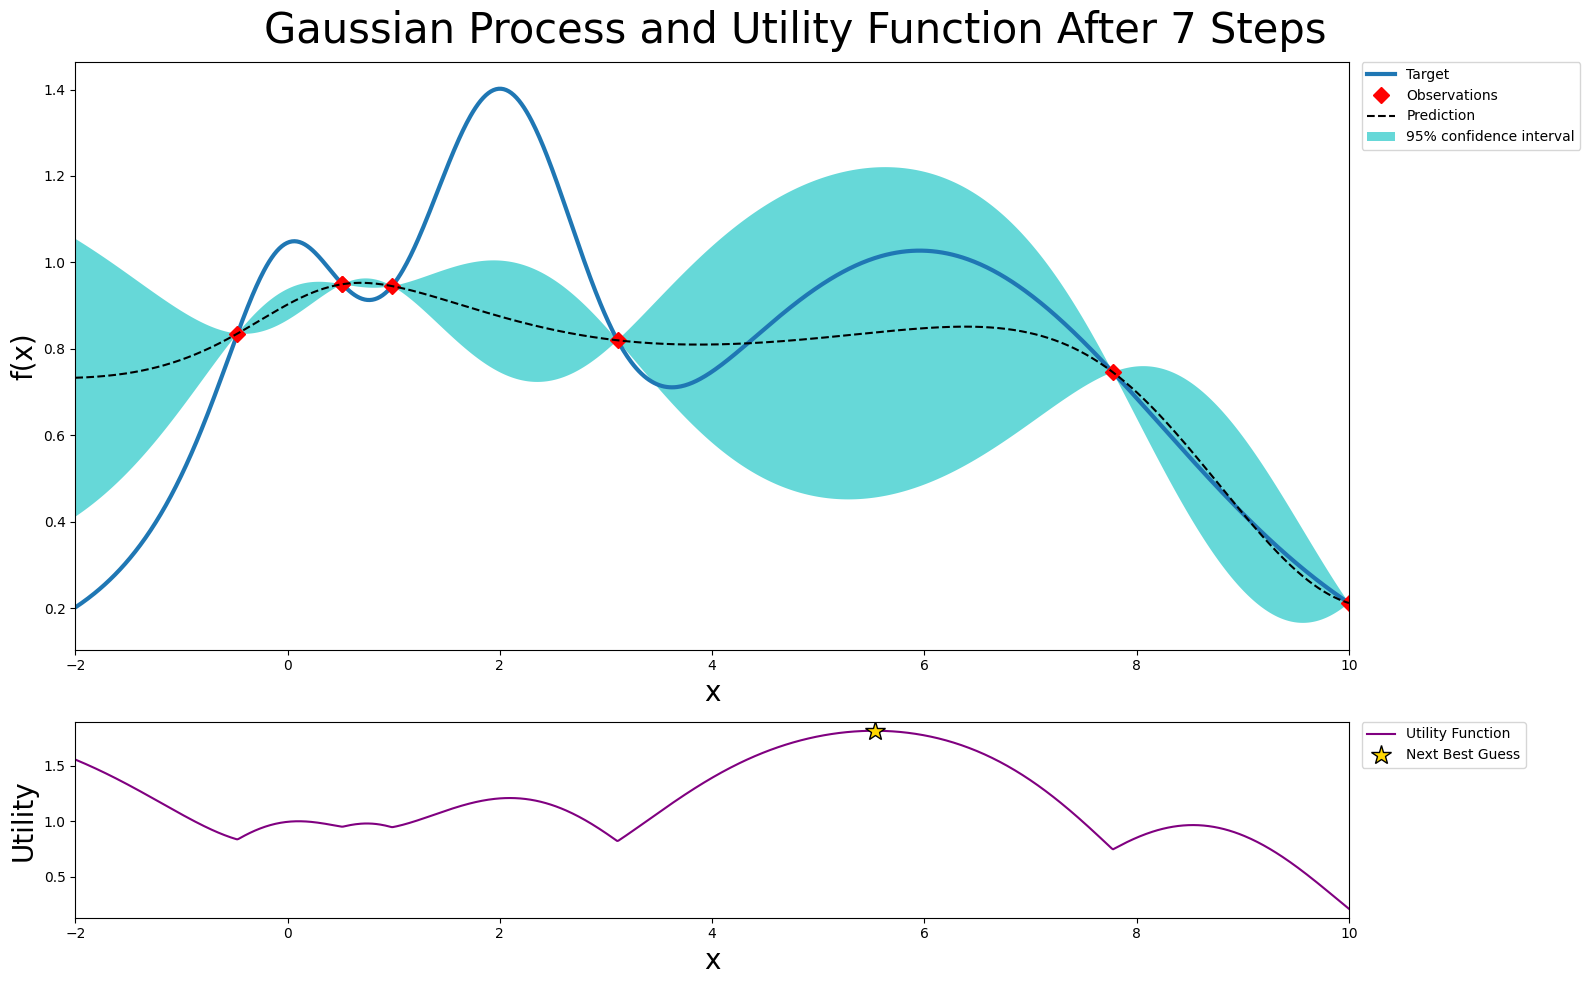

In [16]:
ucb = acquisition.UpperConfidenceBound(kappa=0.1)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print(f"\nUCB Acquisition Function Results (kappa=0.1):")
plot_gp(optimizer_ucb, x, y)


ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print(f"\nUCB Acquisition Function Results (kappa=2.5):")
plot_gp(optimizer_ucb, x, y)


ucb = acquisition.UpperConfidenceBound(kappa=5.0)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print(f"\nUCB Acquisition Function Results (kappa=5.0):")
plot_gp(optimizer_ucb, x, y)




Based on the provided blog, the Upper Confidence Bound (UCB) is an acquisition function that explicitly balances the exploration-exploitation trade-off using a simple weighted sum.

The mathematical formulation is:

$$a_{UCB}(x; \kappa) = \mu(x) + \kappa \cdot \sigma(x)$$

- Exploitation ($\mu(x)$): The predicted mean from the Gaussian Process. It encourages the algorithm to sample in regions where the expected function value is already high.
- Exploration ($\sigma(x)$): The predictive uncertainty (standard deviation) from the Gaussian Process. It encourages the algorithm to sample in uncharted regions where the model is highly uncertain.
- Trade-off Parameter ($\kappa$): Also denoted as $\lambda$ in some literature, this hyperparameter controls how much the algorithm values uncertainty vs. known rewards.

Comparison of Kappa ($\kappa$) Values:
1. $\kappa = 0.1$ (Mostly Exploitation): 

    With a low $\kappa$, the algorithm heavily penalizes uncertainty and acts almost like a purely greedy search. In our execution, it immediately locked onto the first local optimum it found (near $x \approx 0.5$) and spent all its iterations taking micro-steps around it. It failed to explore the broader, highly uncertain regions of the domain, entirely missing the global maximum.

2. $\kappa = 2.5$ (Balanced):

    This parameter provides a healthy balance. The algorithm actively explored the boundaries and wide gaps of the search space (e.g., sampling near $x = -2$ and $x = 7.8$) to reduce global uncertainty, while also investigating promising high-mean areas. By the end of its budget, its utility curve successfully pinpointed the exact location of the true global maximum (near $x = 2$).

3. $\kappa = 5.0$ (Mostly Exploration):

    With a high $\kappa$, the algorithm acts as an obsessive explorer. It is drawn almost exclusively to the widest confidence intervals (highest $\sigma(x)$). Rather than climbing known peaks, it spends its iteration budget bouncing around the largest gaps in the data to flatten the uncertainty bounds across the entire plot. It maps the landscape excellently but delays converging on the actual optimal value.

Exercise 2: Chaotic Acquisition Function
-----------------------------------------
**Goal**: Implement a chaotic acquisition function that exclusively prioritizes the standard deviation of predictions, disregarding the predicted mean. Compare its performance against standard acquisition functions such as UCB and PI (Probability of Improvement).

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.4795761 | -1.056368 |
| 5         | 0.5994353 | 8.3148223 |
| 6         | 0.9551109 | 1.0156908 |
| 7         | 0.9990032 | 5.4116415 |

Chaotic Acquisition Function Results (std only):


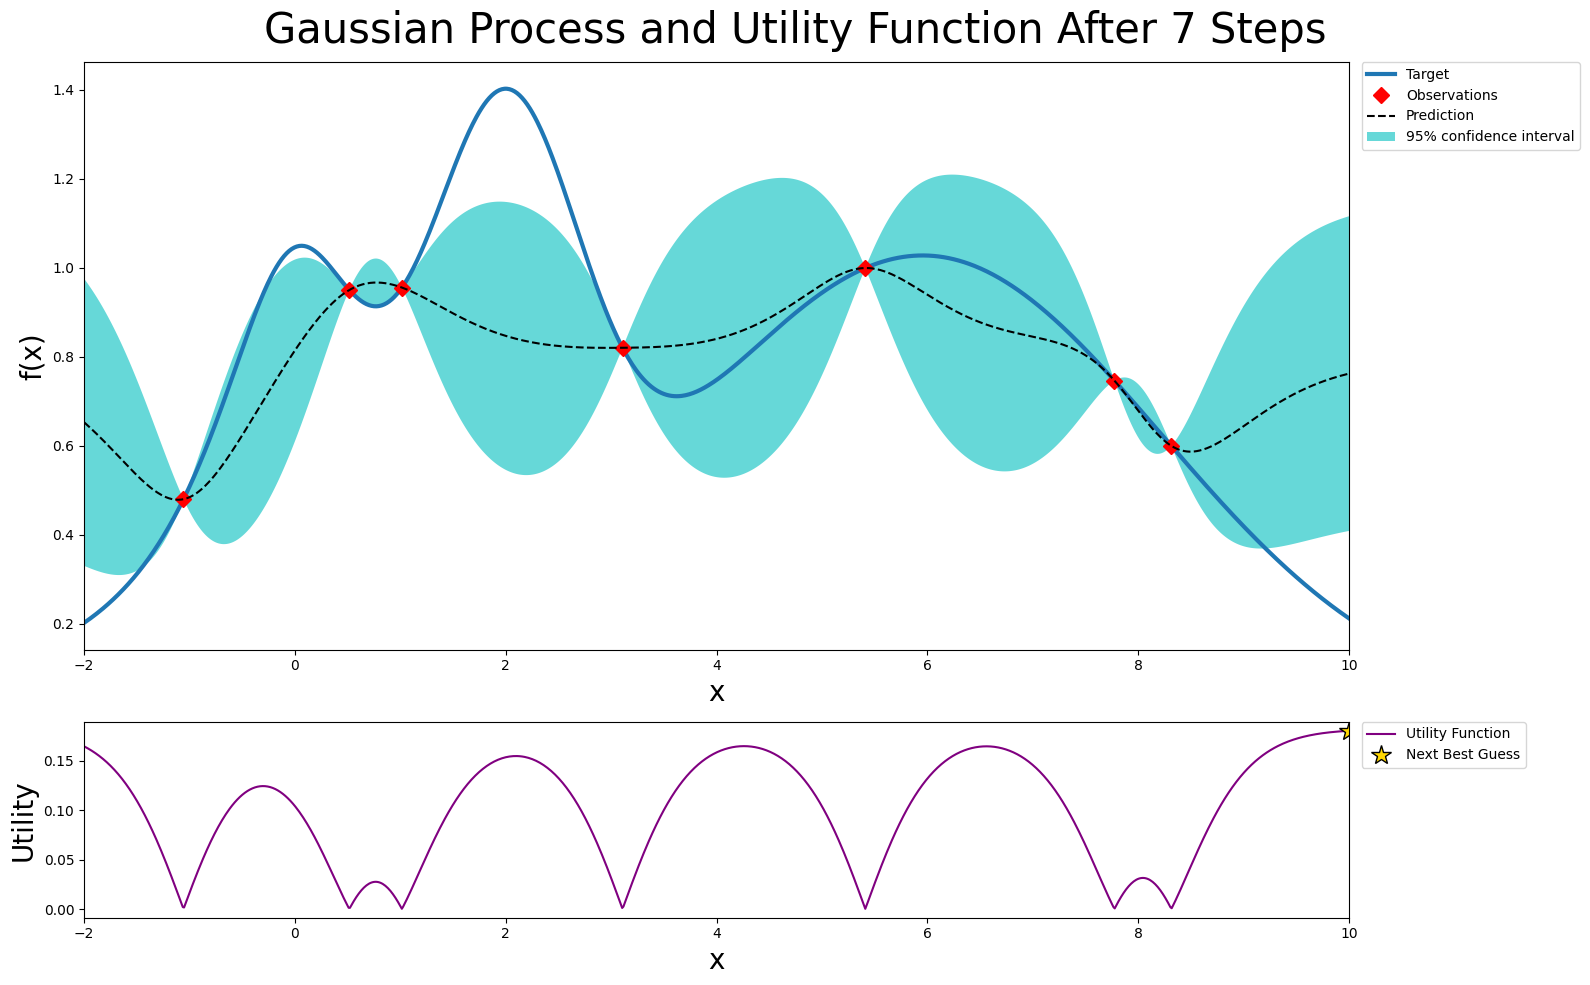

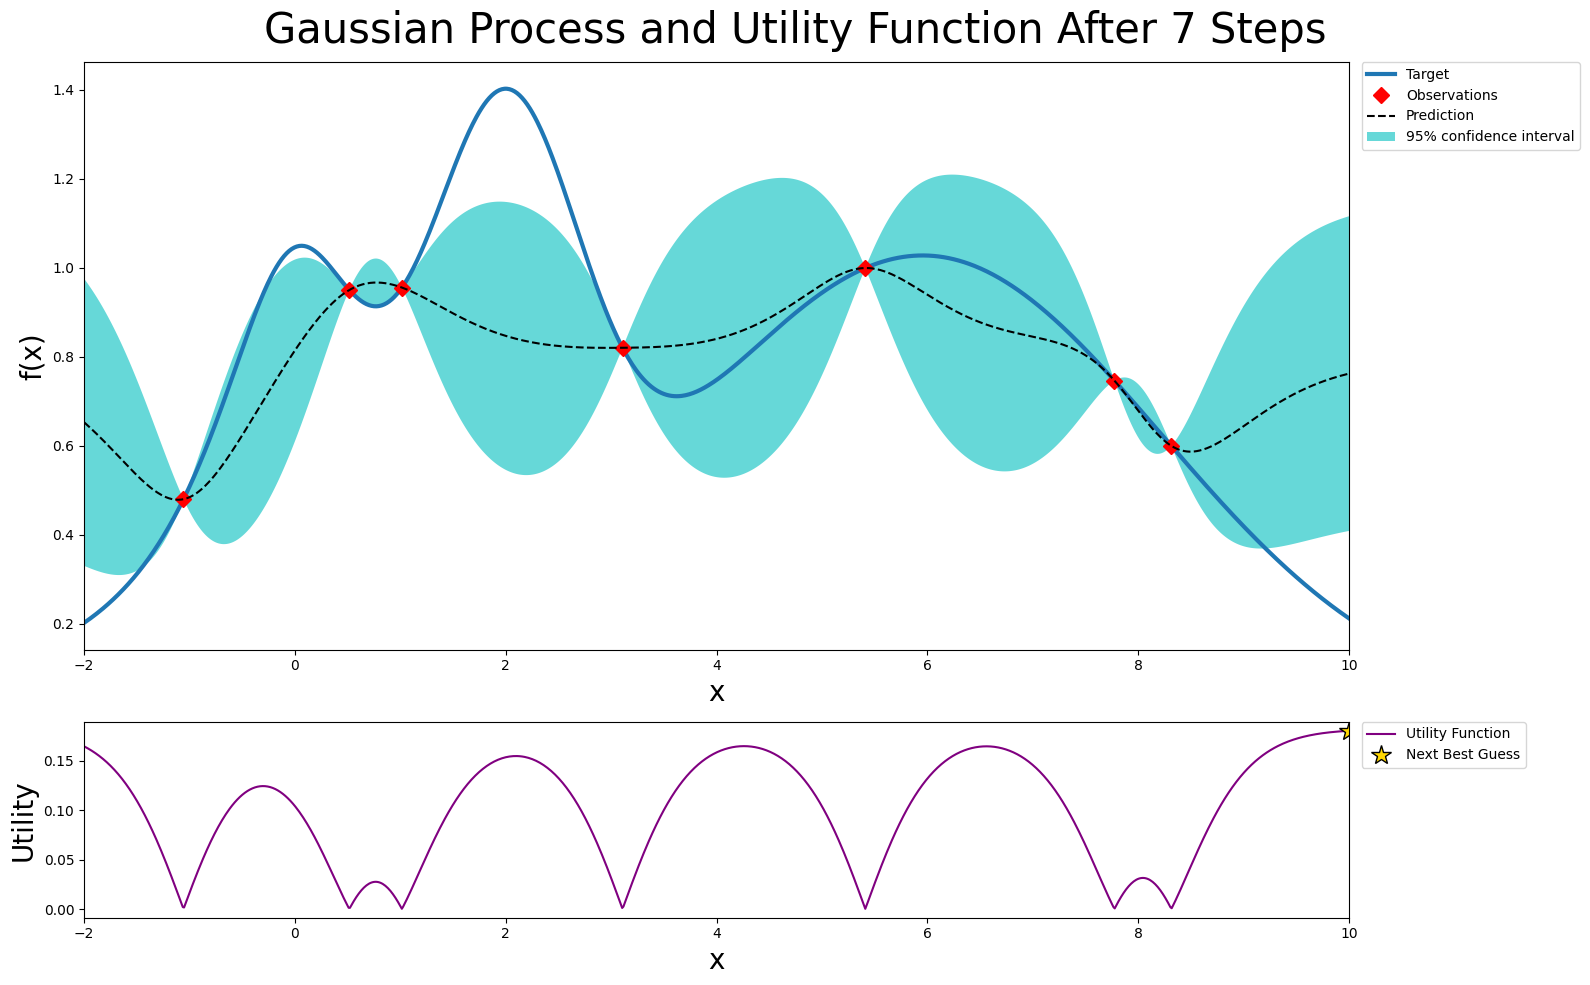

In [19]:
from bayes_opt.acquisition import AcquisitionFunction

class ChaoticAcquisition(AcquisitionFunction):
    """Extremely exploratory acquisition function that heavily favors uncertainty"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return std  
    

chaotic_acquisition = ChaoticAcquisition()
optimizer_chaotic = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=chaotic_acquisition,
    random_state=27,
)

optimizer_chaotic.maximize(init_points=2, n_iter=5)
print(f"\nChaotic Acquisition Function Results (std only):")
plot_gp(optimizer_chaotic, x, y)

Optimization Performance

Unlike UCB or PI, the Chaotic function completely fails to maximize the target function. Because it is entirely blind to the predicted mean (μ), it completely ignores the true global maximum near x=2 and the local maximum near x=0.5.

Behavior
- PI quickly clusters its points around the first good peak it finds (getting trapped in local optima).

- UCB balances exploring boundaries and climbing known peaks.

- Chaotic acts purely as a space-filling algorithm. As seen in the bottom plot, the utility function simply peaks wherever the gaps between data points are widest.



Exercise 3: Expected Improvement
--------------------------------

**Goal:** Implement the Expected Improvement (EI) acquisition function by extending the `AcquisitionFunction` base class provided by the `BayesOpt` library.

Expected Improvement (EI) is a popular choice for the acquisition function. Let's understand its derivation:

1.  **Current Best:** After $n$ evaluations, the best function value observed *so far* is $f^* = \max_{m=1..n} f(x_m)$.

2.  **Potential Improvement:** If we evaluate a new point $x$, the *actual* improvement over the current best $f^*$ is $\max(f(x) - f^*, 0)$, sometimes written as $[f(x) - f^*]^+$.

3.  **The Challenge:** We want to choose $x$ to maximize this improvement, but $f(x)$ is unknown *before* evaluation.

4.  **The Solution: Expected Improvement:** Our probabilistic model gives a posterior distribution for $f(x)$ at any point $x$. Given the data, this is typically a Gaussian distribution: $f(x) \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$. EI maximizes the *expected* value of the improvement, where the expectation is taken over this posterior distribution:

    $EI_n(x) = E_n[ \max(f(x) - f^*, 0) ]$

    This value represents, on average, how much we expect to improve upon $f^*$ by evaluating at $x$. The next point chosen is the one that maximizes $EI_n(x)$.

### Mathematical Formulation

The expected improvement integral can be computed analytically. The standard closed-form expression is:

$$
EI(x) =
\begin{cases}
(\mu(x) - f^*) \Phi(Z) + \sigma(x) \varphi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}
$$

Where:

* $\mu(x)$: The posterior mean of $f(x)$ at point $x$.
* $\sigma(x)$: The posterior standard deviation of $f(x)$ at point $x$.
* $f^*$: The best function value observed so far (a single scalar value).
* $Z = \frac{\mu(x) - f^*}{\sigma(x)}$
* $\Phi(Z)$: The Cumulative Distribution Function (CDF) of the standard normal distribution $\mathcal{N}(0, 1)$.
* $\varphi(Z)$: The Probability Density Function (PDF) of the standard normal distribution $\mathcal{N}(0, 1)$.

### Implementation Task

Create a class `ExpectedImprovement` inheriting from `acquisition.AcquisitionFunction` and implement the core calculation in the `base_acq` method. The signature of `base_acq` method looks like this:
```python
def base_acq(self, mean: NDArray[Float], std: NDArray[Float]) -> NDArray[Float]:
```

Compare its performance against other acquisition functions.

Hint: Analyse the source code of [ProbabilityOfImprovement](https://github.com/bayesian-optimization/BayesianOptimization/blob/d5126dc2462fddf50047519d6ef6125f271e0650/bayes_opt/acquisition.py#L583) class to better understand how to use/update $f^*$ (`self.y_max`).

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495515 | 0.5165758 |
| 5         | 1.0327596 | 0.2129775 |
| 6         | 1.0421903 | -0.026740 |
| 7         | 0.6169657 | -0.804919 |

Expected Improvement Acquisition Function Results:


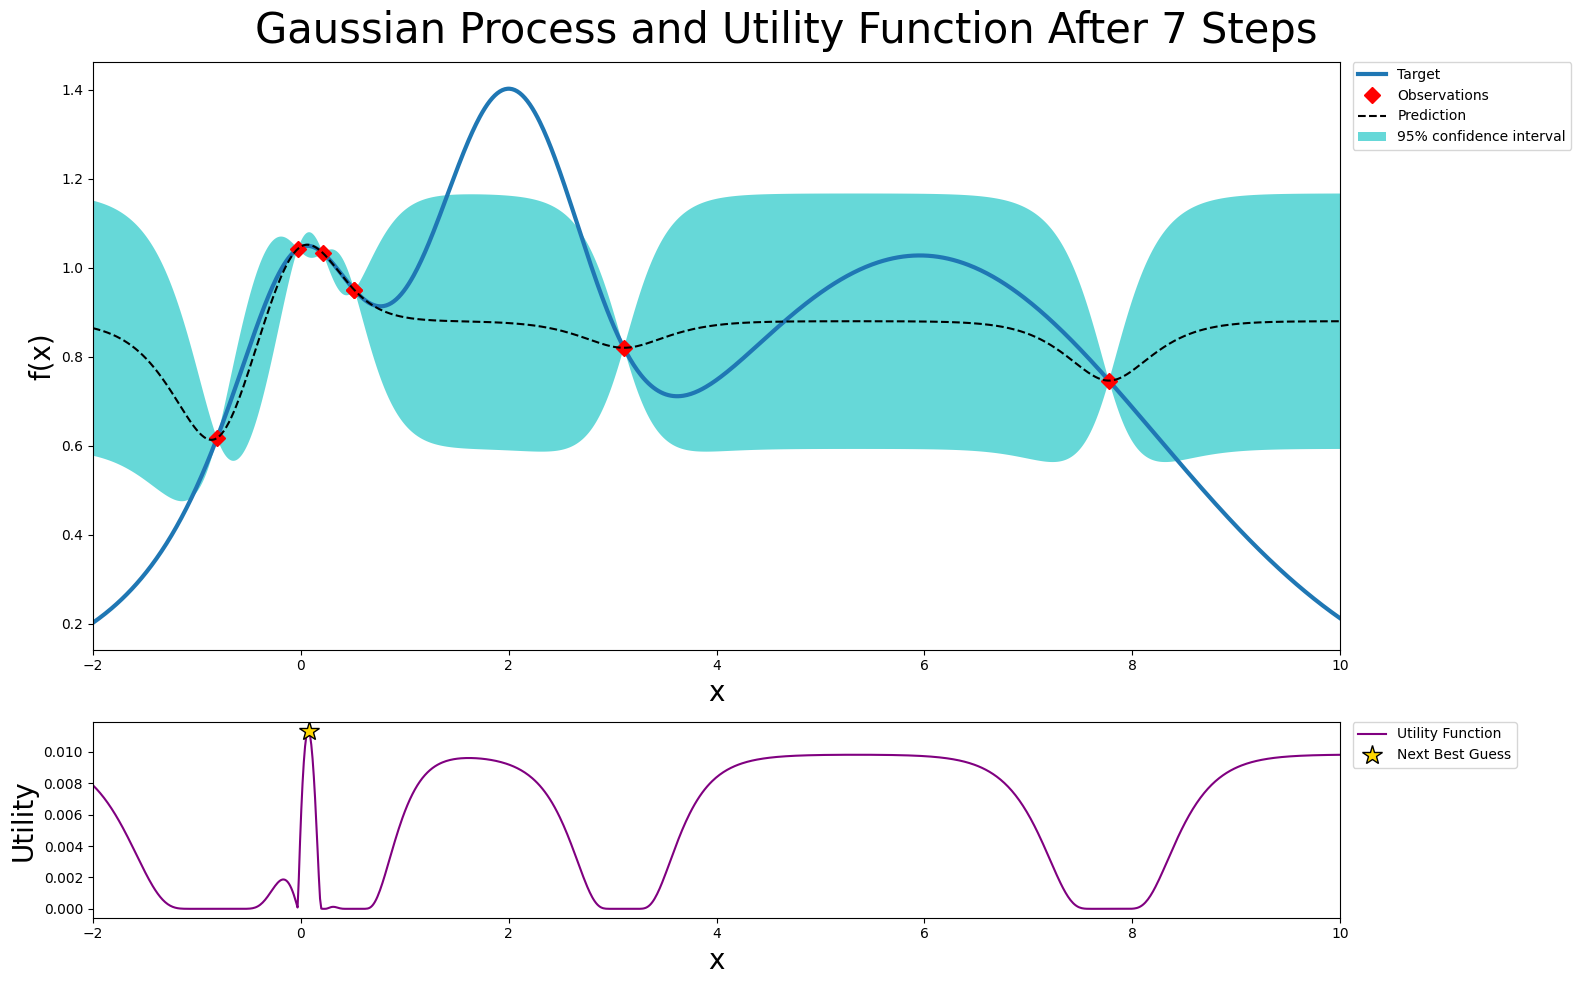

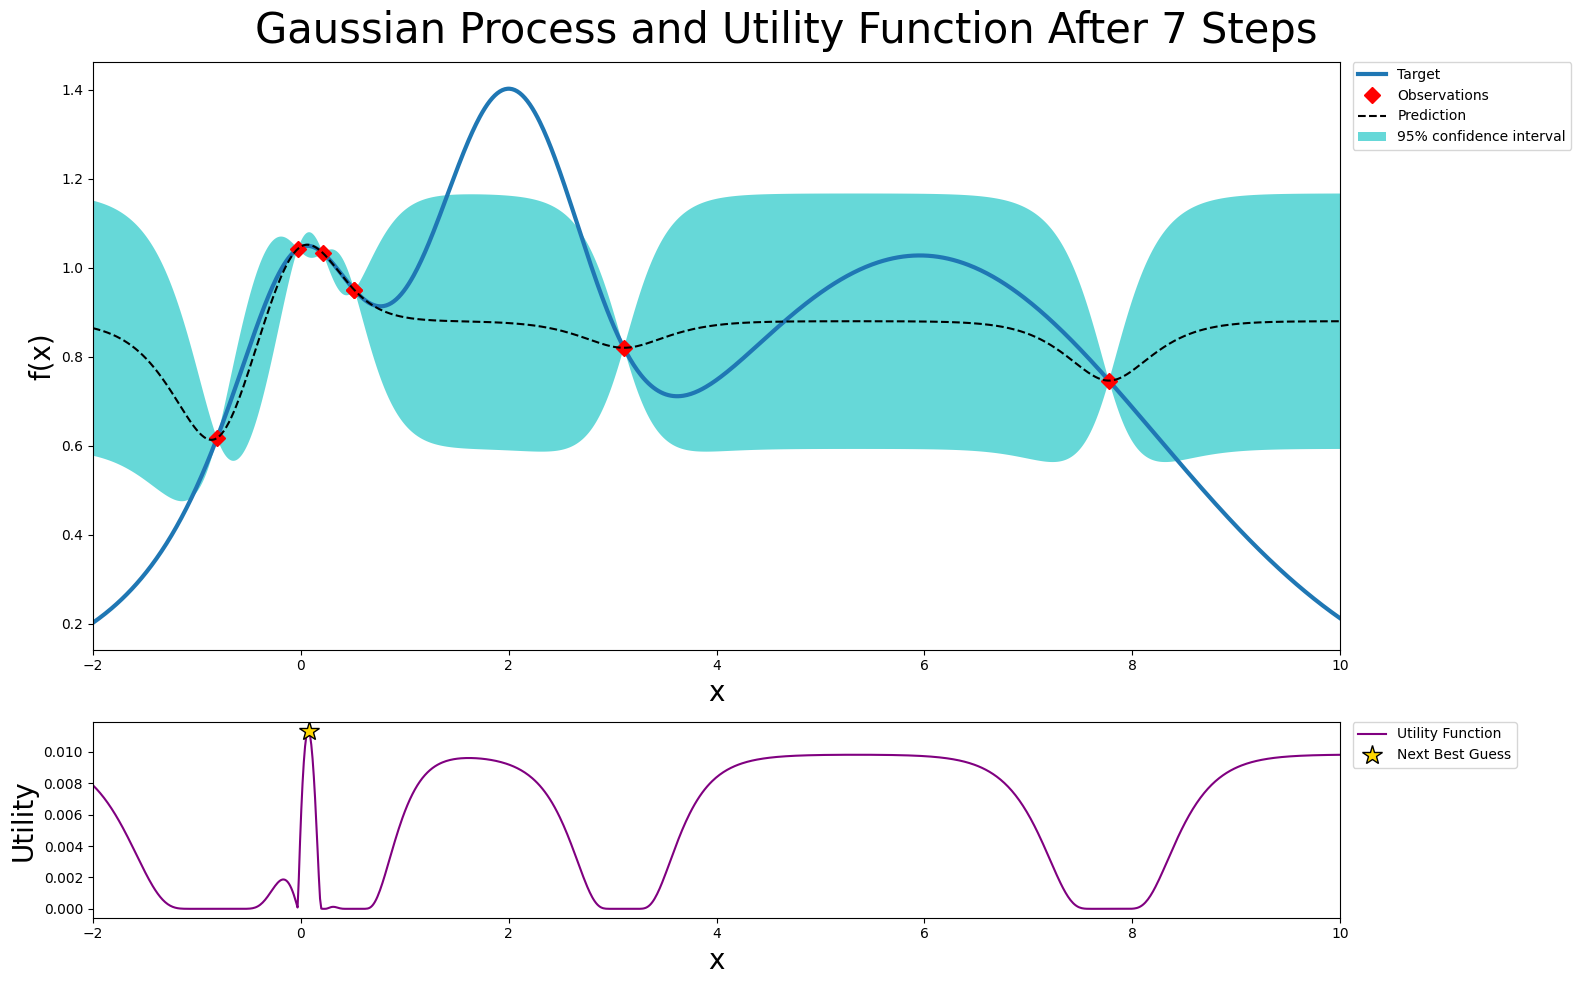

In [ ]:
import scipy.stats

class ExpectedImprovement(acquisition.AcquisitionFunction):
    """Expected Improvement Acquisition Function"""

    def __init__(self, random_state=None):
        super().__init__(random_state)
        self.y_max = None  # will be set to the best observed value

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        safe_std = np.where(std>0, std, 1e-9) # avoid division by zero

        best = self.y_max
        z = (mean - best)/safe_std
        cdf = scipy.stats.norm.cdf(z)
        pdf = scipy.stats.norm.pdf(z)
        ei = (mean - best) * cdf + safe_std * pdf
        
        ei = np.where(std > 0, ei, 0.0) # if std is zero, EI is zero
            
        return ei
    
    def suggest(self, gp, target_space, n_random=10000, n_smart=10, fit_gp=True, random_state=None):        
        self.y_max = target_space._target_max()       
        return super().suggest(
            gp=gp,
            target_space=target_space,
            n_random=n_random,
            n_smart=n_smart,
            fit_gp=fit_gp,
            random_state=random_state
        )
    
ei_acquisition = ExpectedImprovement()
optimizer_ei = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ei_acquisition,
    random_state=27,
)
optimizer_ei.maximize(init_points=2, n_iter=5)
print(f"\nExpected Improvement Acquisition Function Results:")
plot_gp(optimizer_ei, x, y)


Exercise 4: Theoretical Questions
--------------------------------
1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?
2. Compare and contrast the different acquisition functions discussed in this tutorial.
3. What are the limitations of Bayesian Optimization?

1. Why is Bayesian Optimization useful for expensive functions?

    Bayesian Optimization is specifically designed to find the global optimum of a "black-box" function in as few evaluations as possible. It is efficient because:

- Surrogate Modeling: It builds a cheap-to-evaluate mathematical model (usually a Gaussian Process) that mimics the expensive objective function.

- Sample Efficiency: Instead of random or grid searching, it uses the surrogate model to "think" before "doing," strategically selecting only the most promising points.

- Reduced Cost: By minimizing the number of evaluations, it saves significant time and resources (e.g., CPU hours, laboratory materials, or financial costs).

2. Comparison of Acquisition Functions

- UCB: High $\kappa$ forces exploration; low $\kappa$ forces exploitation. Very flexible and reliable for mapping.
- PI: Purely Exploitative. It looks for a "sure win," often getting stuck in local optima
- EI: It weighs both the probability and the magnitude of potential improvement. It is less likely to get stuck than PI.
- Chaotic: Pure Exploration. It builds a perfect map of the entire space but fails as an optimizer because it ignores where the high values actually are.

3. What are the limitations of Bayesian Optimization?
- Dimensionality: BO performs best in low-to-medium dimensions (typically $<20$ parameters). In very high-dimensional spaces, the surrogate model becomes computationally expensive and less accurate.
- Computational Overhead: The time taken to update the Gaussian Process and optimize the acquisition function can be significant. If the target function is "cheap" (evaluates in milliseconds), BO might actually be slower than simple Random Search
- Model Dependency: The performance is only as good as the surrogate model. If the underlying function is extremely discontinuous or non-stationary, the Gaussian Process may fail to capture its shape, leading to poor suggestions.